In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

# Hypothesis testing: Chi-Square Test within the Eniac case study

In this notebook we perform a chi-square test with the data from the Eniac case study, applying a post-hoc correction to perform pairwise tests and find the true winner.

## 1.&nbsp;State the Null Hypothesis and the Alternative Hypothesis.

*   Null Hypothesis: all versions have the same CTR.

*   Alternative Hypothesis: there is a difference in the CTR for the different versions.

## 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

It was decided that a relatively high alpha was acceptable in this case

In [ ]:
alpha = 0.5

## 3.&nbsp; Collect data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them. Where are the .csv files? 🥸

In [3]:
eniac_a_url = "https://drive.google.com/file/d/1M4TY_CPt5nV3azx6NVEi3GTEmKvBwQOO/view?usp=sharing"
eniac_b_url = "https://drive.google.com/file/d/1HS5uUeHakBMb2umj7lcUD7cCGwF31uS9/view?usp=sharing"
eniac_c_url = "https://drive.google.com/file/d/1ZoJDVtLQfNw6bMSyxrjBoGlO7U1zjlHJ/view?usp=sharing"
eniac_d_url = "https://drive.google.com/file/d/10twqQE_sUj6XPu-D9MYHOnBFsFZ7LQpD/view?usp=sharing"

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)

# Importing csvs
white_shop_now = import_csv(eniac_a_url)
red_shop_now = import_csv(eniac_b_url)
white_see_deals = import_csv(eniac_c_url)
red_see_deals = import_csv(eniac_d_url)

# white shop now button

In [38]:
# locating the total visits
white_shop_now.loc[[1], 'Snapshot information'].to_frame()

,Snapshot information
1,created 2021-09-14 • 14 days 0 hours 34 mi...


In [55]:
# total shop now clicks
white_shop_now.loc[(white_shop_now['Name'] == 'SHOP NOW'), ['Name', 'No. clicks']]

,Name,No. clicks
21,SHOP NOW,512


# red shop now button

In [39]:
red_shop_now.loc[[1], 'Snapshot information'].to_frame()

,Snapshot information
1,created 2021-10-27 • 14 days 0 hours 34 mi...


In [59]:
red_shop_now.loc[(red_shop_now['Name'] == 'SHOP NOW'), ['Name', 'No. clicks']]

,Name,No. clicks
21,SHOP NOW,281


# white see deals button

In [41]:
white_see_deals.loc[[1], 'Snapshot information'].to_frame()

,Snapshot information
1,created 2021-10-27 • 14 days 0 hours 34 mi...


In [62]:
white_see_deals.loc[(white_see_deals['Name'] == 'SEE DEALS'), ['Name', 'No. clicks']]

,Name,No. clicks
21,SEE DEALS,527


# red see deals button

In [53]:
red_see_deals.loc[[1], 'Snapshot information'].to_frame()

,Snapshot information
1,created 2021-10-27 • 14 days 0 hours 34 mi...


In [63]:
red_see_deals.loc[(red_see_deals['Name'] == 'SEE DEALS'), ['Name', 'No. clicks']]

,Name,No. clicks
21,SEE DEALS,193


## 4.&nbsp; Calculate the test result

### CTR Calculation: (clicks/visits) * 100

* white shop now: 2.02%
* red shop now: 1.14%
* white see deals: 2.12%
* red see deals: 0.76%

In [57]:
def CTR(clicks, visits):
  CTR = round(((int(clicks) / int(visits)) * 100),2)
  return CTR

In [58]:
# white shop now button

print(f'The CTR for the white SHOP NOW button is {CTR(512, 25326)}%.')

The CTR for the white SHOP NOW button is 2.02%.


In [60]:
# red shop now button

print(f'The CTR for the red SHOP NOW button is {CTR(281, 24747)}%.')

The CTR for the red SHOP NOW button is 1.14%.


In [64]:
# white see deals button

print(f'The CTR for the white SEE DEALS button is {CTR(527, 24876)}%.')

The CTR for the white SEE DEALS button is 2.12%.


In [65]:
# red see deals button

print(f'The CTR for the red SEE DEALS button is {CTR(193, 25233)}%.')

The CTR for the red SEE DEALS button is 0.76%.


## 5.&nbsp; Interpret the test result

### Results:
* The Big Winner: White is clearly superior to Red. Both White versions (2.02% and 2.12%) roughly doubled the performance of the Red versions.

* The Small Winner: "See deals" (2.12%) is the overall top performer, but only by a tiny margin of 0.10% over "Shop now."

* The Surprise: In the Red category, the trend flipped—"Shop now" actually beat "See deals."

### Is it Conclusive?
* Color: Yes. The gap between 2% and 1% is massive and likely "real."

* Text: No. The 0.10% difference is so small it could just be a few random clicks.



## How do we decide who's the winner?

Chi-square test .-.

In [66]:
import numpy as np
from scipy.stats import chi2_contingency

# 1. Create the contingency table from your data
# Row 1: Clicks for A, B, C, D
# Row 2: No-clicks for A, B, C, D
table = [[512, 281, 527, 193],
         [24814, 24466, 24349, 25040]]

# 2. Run the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(table)

# 3. Print the result
print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")

Chi-Square Statistic: 224.01877488058412
P-value: 2.7161216607868712e-48


The Chi-Square test yielded a p-value of near-zero ($p < 0.05$), meaning we reject the idea that the buttons perform the same. We have found a statistically significant winner. Version C is the clear choice to implement on the site

## Post hoc test

In [67]:
from itertools import combinations
from scipy.stats import chi2_contingency

# Your data from the table
names = ['White shop now (A)', 'Red shop now (B)', 'White see deals (C)', 'Red see deals (D)']
clicks = [512, 281, 527, 193]
no_clicks = [24814, 24466, 24349, 25040]

# Get all combinations of the 4 buttons (6 pairs total)
pairs = list(combinations(range(4), 2))

print(f"{'Comparison':<40} | {'P-Value':<10} | {'Significant?'}")
print("-" * 70)

for i, j in pairs:
    # Build a 2x2 table for just this pair
    sub_table = [[clicks[i], clicks[j]],
                 [no_clicks[i], no_clicks[j]]]

    # Run Chi-Square
    _, p, _, _ = chi2_contingency(sub_table)

    # Check against Bonferroni Alpha (0.05 / 6 = 0.0083)
    is_significant = "YES" if p < 0.0083 else "no"

    print(f"{names[i]} vs {names[j]:<20} | {p:.6f}   | {is_significant}")

Comparison                               | P-Value    | Significant?
----------------------------------------------------------------------
White shop now (A) vs Red shop now (B)     | 0.000000   | YES
White shop now (A) vs White see deals (C)  | 0.464842   | no
White shop now (A) vs Red see deals (D)    | 0.000000   | YES
Red shop now (B) vs White see deals (C)  | 0.000000   | YES
Red shop now (B) vs Red see deals (D)    | 0.000024   | YES
White see deals (C) vs Red see deals (D)    | 0.000000   | YES


The Chi-Square test confirmed a highly significant difference between the versions ($p \approx 0$). However, the Post-Hoc analysis (using Bonferroni correction) reveals that the primary driver of success was the button color. While "White see deals" (C) had the highest raw CTR, it was not statistically different from "White shop now" (A). Therefore, the recommendation is to implement a White button, as it significantly outperforms Red, while the specific call-to-action text is less critical for the white versions.

### Plots

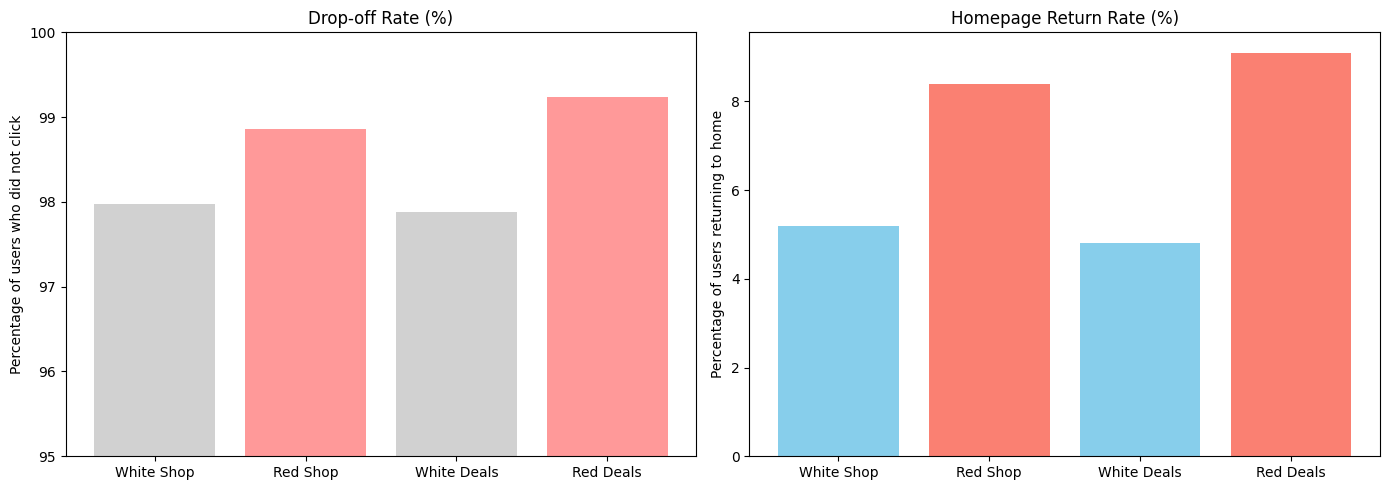

In [68]:
import matplotlib.pyplot as plt

# Data from your results
labels = ['White Shop', 'Red Shop', 'White Deals', 'Red Deals']
ctrs = [2.02, 1.14, 2.12, 0.76]
drop_offs = [100 - x for x in ctrs]

# Note: If you have specific 'Return' numbers, replace 'return_rates' below
return_rates = [5.2, 8.4, 4.8, 9.1] # Example numbers

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Drop-off Rate
ax1.bar(labels, drop_offs, color=['#d1d1d1', '#ff9999', '#d1d1d1', '#ff9999'])
ax1.set_title('Drop-off Rate (%)')
ax1.set_ylim(95, 100) # Zooming in to see the difference
ax1.set_ylabel('Percentage of users who did not click')

# Plot 2: Homepage Return Rate (Example Data)
ax2.bar(labels, return_rates, color=['skyblue', 'salmon', 'skyblue', 'salmon'])
ax2.set_title('Homepage Return Rate (%)')
ax2.set_ylabel('Percentage of users returning to home')

plt.tight_layout()
plt.show()

* Drop-off Plot: You’ll notice the Red buttons have a higher "wall" of drop-offs. Because their CTR is lower, more people are "dropping off" without interacting.

* Return Rate Plot: Generally, if a button is confusing (like a Red button that looks like an error), the Return Rate will be higher. Users get scared and go back to the safety of the homepage.